# Penalty Winner Region Sweep

This notebook evaluates one penalty ensemble on the full `2000`-instance test set, sweeps multiple 1D and 2D metrics, and shows the best separating views for member winners.


In [80]:
import glob
import itertools
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset

from utils.evaluator import Evaluator
from utils.trainer import DEVICE, create_model, load_instance


## Config

In [81]:
RUN_DIR = 'results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003102_penalty_seed0_e1000_lr1e-04_n7000_ens5_vanilla_pre'
OUT_PNG_1D = 'results/penalty_seed0_best_1d_metric.png'
OUT_PNG_2D = 'results/penalty_seed0_best_2d_metric.png'
SUBSET_N = 2000
BATCH_SIZE = 128
MERIT_EQ_WEIGHT = 1e5
MERIT_INEQ_WEIGHT = 1e5
MIN_WINS_TO_PLOT = 10


print('run_dir:', RUN_DIR)
print('subset_n:', SUBSET_N)
print('out_png_1d:', OUT_PNG_1D)
print('out_png_2d:', OUT_PNG_2D)
print('device:', DEVICE)


run_dir: results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260316-003102_penalty_seed0_e1000_lr1e-04_n7000_ens5_vanilla_pre
subset_n: 2000
out_png_1d: results/penalty_seed0_best_1d_metric.png
out_png_2d: results/penalty_seed0_best_2d_metric.png
device: cpu


## Helpers

In [82]:
def resolve_checkpoints(run_dir):
    pattern = os.path.join(run_dir, 'members', 'member_[0-9]*.pt')
    member_files = sorted(
        [
            f for f in glob.glob(pattern)
            if os.path.basename(f).startswith('member_') and '_epoch_' not in os.path.basename(f)
        ]
    )
    if member_files:
        return member_files
    model_pt = os.path.join(run_dir, 'model.pt')
    if os.path.isfile(model_pt):
        return [model_pt]
    raise FileNotFoundError(f'No model.pt or members/member_*.pt found in {run_dir}')


def load_single_model(ckpt_path, opt_problem):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    config = ckpt['config']
    model = create_model(opt_problem, config['method'], config)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model, config


def evaluate_member(model, evaluator, dataset, batch_size=128):
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    out = {
        k: []
        for k in [
            'merit',
            'training_loss',
            'objective',
            'eq_violation_l1',
            'ineq_violation_l1',
            'eq_violation_sq',
            'ineq_violation_sq',
        ]
    }
    method_cfg = evaluator.config_method

    for x_batch, _ in loader:
        x_batch = x_batch.to(DEVICE)
        with torch.no_grad():
            y_pred = evaluator.opt_problem.scale(model(x_batch))
            objective = evaluator.opt_problem.obj_fn(y_pred)
            eq_resid = evaluator.opt_problem.eq_resid(x_batch, y_pred)
            ineq_resid = evaluator.opt_problem.ineq_resid(x_batch, y_pred)
            eq_violation_l1 = eq_resid.abs().sum(dim=1)
            ineq_violation_l1 = ineq_resid.abs().sum(dim=1)
            eq_violation_sq = eq_resid.square().sum(dim=1)
            ineq_violation_sq = ineq_resid.square().sum(dim=1)
            merit = objective + MERIT_EQ_WEIGHT * eq_violation_l1 + MERIT_INEQ_WEIGHT * ineq_violation_l1
            training_loss = (
                method_cfg['obj_weight'] * objective
                + method_cfg['eq_pen_weight'] * eq_violation_sq
                + method_cfg['ineq_pen_weight'] * ineq_violation_sq
            )

        for k, v in {
            'merit': merit,
            'training_loss': training_loss,
            'objective': objective,
            'eq_violation_l1': eq_violation_l1,
            'ineq_violation_l1': ineq_violation_l1,
            'eq_violation_sq': eq_violation_sq,
            'ineq_violation_sq': ineq_violation_sq,
        }.items():
            out[k].append(v.detach().cpu().numpy())

    return {k: np.concatenate(v) for k, v in out.items()}


def score_qda(features, labels):
    x_train, x_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.3, random_state=0, stratify=labels
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=ConvergenceWarning)
        warnings.simplefilter('ignore', category=UserWarning)
        clf = QuadraticDiscriminantAnalysis(reg_param=1e-3)
        clf.fit(x_train, y_train)
        pred = clf.predict(x_test)
    return balanced_accuracy_score(y_test, pred)


def print_table(headers, rows, floatfmt='{:.4f}', max_rows=None):
    rows = list(rows)
    if max_rows is not None:
        rows = rows[:max_rows]
    formatted = []
    for row in rows:
        cur = []
        for val in row:
            if isinstance(val, (float, np.floating)):
                cur.append(floatfmt.format(float(val)))
            else:
                cur.append(str(val))
        formatted.append(cur)
    widths = [len(str(h)) for h in headers]
    for row in formatted:
        for i, val in enumerate(row):
            widths[i] = max(widths[i], len(val))
    print(' | '.join(str(h).ljust(widths[i]) for i, h in enumerate(headers)))
    print('-+-'.join('-' * widths[i] for i in range(len(headers))))
    for row in formatted:
        print(' | '.join(row[i].ljust(widths[i]) for i in range(len(headers))))


## Evaluate Members On Test Instances

In [83]:
ckpts = resolve_checkpoints(RUN_DIR)
first = torch.load(ckpts[0], map_location='cpu', weights_only=False)
cfg = dict(first['config'])
cfg['_eval_only'] = True

problem, _ = load_instance(cfg)
evaluator = Evaluator(problem, cfg['method'], cfg)
x_test, y_test = problem.test_dataset.tensors
if SUBSET_N > len(x_test):
    raise RuntimeError(f'SUBSET_N={SUBSET_N} exceeds test set size {len(x_test)}')
subset = TensorDataset(x_test[:SUBSET_N], y_test[:SUBSET_N])

member_out = []
for i, ckpt in enumerate(ckpts):
    print(f'evaluating member {i}...')
    model, _ = load_single_model(ckpt, problem)
    member_out.append(evaluate_member(model, evaluator, subset, batch_size=BATCH_SIZE))

arrays = {k: np.stack([m[k] for m in member_out], axis=0) for k in member_out[0].keys()}
n_members, n_points = arrays['merit'].shape
winner = arrays['merit'].argmin(axis=0)
idx = np.arange(n_points)

winner_counts = np.bincount(winner, minlength=n_members)
active_members = np.where(winner_counts >= MIN_WINS_TO_PLOT)[0]
plot_mask = np.isin(winner, active_members)

merit_sorted = np.sort(arrays['merit'], axis=0)
training_loss_sorted = np.sort(arrays['training_loss'], axis=0)
objective_sorted = np.sort(arrays['objective'], axis=0)
eq_sorted = np.sort(arrays['eq_violation_l1'], axis=0)
ineq_sorted = np.sort(arrays['ineq_violation_l1'], axis=0)
eq_sq_sorted = np.sort(arrays['eq_violation_sq'], axis=0)
ineq_sq_sorted = np.sort(arrays['ineq_violation_sq'], axis=0)

winner_merit = arrays['merit'][winner, idx]
winner_training_loss = arrays['training_loss'][winner, idx]
winner_objective = arrays['objective'][winner, idx]
winner_eq_violation_l1 = arrays['eq_violation_l1'][winner, idx]
winner_ineq_violation_l1 = arrays['ineq_violation_l1'][winner, idx]
winner_eq_violation_sq = arrays['eq_violation_sq'][winner, idx]
winner_ineq_violation_sq = arrays['ineq_violation_sq'][winner, idx]

pairwise_merit = []
pairwise_training_loss = []
pairwise_objective = []
pairwise_eq = []
pairwise_ineq = []
pairwise_eq_sq = []
pairwise_ineq_sq = []
for i in range(n_members):
    for j in range(i + 1, n_members):
        pairwise_merit.append(np.abs(arrays['merit'][i] - arrays['merit'][j]))
        pairwise_training_loss.append(np.abs(arrays['training_loss'][i] - arrays['training_loss'][j]))
        pairwise_objective.append(np.abs(arrays['objective'][i] - arrays['objective'][j]))
        pairwise_eq.append(np.abs(arrays['eq_violation_l1'][i] - arrays['eq_violation_l1'][j]))
        pairwise_ineq.append(np.abs(arrays['ineq_violation_l1'][i] - arrays['ineq_violation_l1'][j]))
        pairwise_eq_sq.append(np.abs(arrays['eq_violation_sq'][i] - arrays['eq_violation_sq'][j]))
        pairwise_ineq_sq.append(np.abs(arrays['ineq_violation_sq'][i] - arrays['ineq_violation_sq'][j]))

pairwise_merit = np.stack(pairwise_merit, axis=0)
pairwise_training_loss = np.stack(pairwise_training_loss, axis=0)
pairwise_objective = np.stack(pairwise_objective, axis=0)
pairwise_eq = np.stack(pairwise_eq, axis=0)
pairwise_ineq = np.stack(pairwise_ineq, axis=0)
pairwise_eq_sq = np.stack(pairwise_eq_sq, axis=0)
pairwise_ineq_sq = np.stack(pairwise_ineq_sq, axis=0)


evaluating member 0...
evaluating member 1...
evaluating member 2...
evaluating member 3...
evaluating member 4...


In [84]:
metrics = {
    'winner_merit': winner_merit,
    'winner_training_loss': winner_training_loss,
    'winner_objective': winner_objective,
    'winner_eq_violation_l1': winner_eq_violation_l1,
    'winner_ineq_violation_l1': winner_ineq_violation_l1,
    'winner_eq_violation_sq': winner_eq_violation_sq,
    'winner_ineq_violation_sq': winner_ineq_violation_sq,
    'best_merit': merit_sorted[0],
    'best_training_loss': training_loss_sorted[0],
    'best_objective': objective_sorted[0],
    'best_eq_violation_l1': eq_sorted[0],
    'best_ineq_violation_l1': ineq_sorted[0],
    'best_eq_violation_sq': eq_sq_sorted[0],
    'best_ineq_violation_sq': ineq_sq_sorted[0],
    'merit_margin_top1_top2': merit_sorted[1] - merit_sorted[0],
    'training_loss_margin_top1_top2': training_loss_sorted[1] - training_loss_sorted[0],
    'merit_margin_top1_mean_rest': arrays['merit'].mean(axis=0) - merit_sorted[0],
    'training_loss_margin_top1_mean_rest': arrays['training_loss'].mean(axis=0) - training_loss_sorted[0],
    'merit_disagree_std': arrays['merit'].std(axis=0),
    'merit_disagree_range': arrays['merit'].max(axis=0) - arrays['merit'].min(axis=0),
    'training_loss_mean': arrays['training_loss'].mean(axis=0),
    'training_loss_std': arrays['training_loss'].std(axis=0),
    'training_loss_range': arrays['training_loss'].max(axis=0) - arrays['training_loss'].min(axis=0),
    'objective_mean': arrays['objective'].mean(axis=0),
    'objective_std': arrays['objective'].std(axis=0),
    'objective_range': arrays['objective'].max(axis=0) - arrays['objective'].min(axis=0),
    'eq_violation_l1_mean': arrays['eq_violation_l1'].mean(axis=0),
    'eq_violation_l1_std': arrays['eq_violation_l1'].std(axis=0),
    'eq_violation_l1_range': arrays['eq_violation_l1'].max(axis=0) - arrays['eq_violation_l1'].min(axis=0),
    'ineq_violation_l1_mean': arrays['ineq_violation_l1'].mean(axis=0),
    'ineq_violation_l1_std': arrays['ineq_violation_l1'].std(axis=0),
    'ineq_violation_l1_range': arrays['ineq_violation_l1'].max(axis=0) - arrays['ineq_violation_l1'].min(axis=0),
    'eq_violation_sq_mean': arrays['eq_violation_sq'].mean(axis=0),
    'eq_violation_sq_std': arrays['eq_violation_sq'].std(axis=0),
    'eq_violation_sq_range': arrays['eq_violation_sq'].max(axis=0) - arrays['eq_violation_sq'].min(axis=0),
    'ineq_violation_sq_mean': arrays['ineq_violation_sq'].mean(axis=0),
    'ineq_violation_sq_std': arrays['ineq_violation_sq'].std(axis=0),
    'ineq_violation_sq_range': arrays['ineq_violation_sq'].max(axis=0) - arrays['ineq_violation_sq'].min(axis=0),
    'pairwise_merit_mean': pairwise_merit.mean(axis=0),
    'pairwise_merit_range': pairwise_merit.max(axis=0) - pairwise_merit.min(axis=0),
    'pairwise_training_loss_mean': pairwise_training_loss.mean(axis=0),
    'pairwise_training_loss_range': pairwise_training_loss.max(axis=0) - pairwise_training_loss.min(axis=0),
    'pairwise_objective_mean': pairwise_objective.mean(axis=0),
    'pairwise_objective_range': pairwise_objective.max(axis=0) - pairwise_objective.min(axis=0),
    'pairwise_eq_violation_l1_mean': pairwise_eq.mean(axis=0),
    'pairwise_eq_violation_l1_range': pairwise_eq.max(axis=0) - pairwise_eq.min(axis=0),
    'pairwise_ineq_violation_l1_mean': pairwise_ineq.mean(axis=0),
    'pairwise_ineq_violation_l1_range': pairwise_ineq.max(axis=0) - pairwise_ineq.min(axis=0),
    'pairwise_eq_violation_sq_mean': pairwise_eq_sq.mean(axis=0),
    'pairwise_eq_violation_sq_range': pairwise_eq_sq.max(axis=0) - pairwise_eq_sq.min(axis=0),
    'pairwise_ineq_violation_sq_mean': pairwise_ineq_sq.mean(axis=0),
    'pairwise_ineq_violation_sq_range': pairwise_ineq_sq.max(axis=0) - pairwise_ineq_sq.min(axis=0),
}

metrics['ineq_over_eq_violation'] = metrics['ineq_violation_l1_mean'] / (metrics['eq_violation_l1_mean'] + 1e-9)
metrics['ineq_over_eq_violation_sq'] = metrics['ineq_violation_sq_mean'] / (metrics['eq_violation_sq_mean'] + 1e-9)
metrics['training_loss_x_objective_disagree'] = metrics['training_loss_std'] * metrics['objective_std']
metrics['training_loss_x_violation_disagree'] = metrics['training_loss_std'] * (
    metrics['eq_violation_sq_std'] + metrics['ineq_violation_sq_std']
)
metrics['merit_x_objective_disagree'] = metrics['merit_disagree_std'] * metrics['objective_std']
metrics['merit_x_violation_disagree'] = metrics['merit_disagree_std'] * (
    metrics['eq_violation_l1_std'] + metrics['ineq_violation_l1_std']
)

print('winner counts:', winner_counts.tolist())
print('active members:', active_members.tolist())
print('points kept:', int(plot_mask.sum()))
print('n_metrics:', len(metrics))
if len(active_members) < 2:
    raise RuntimeError('Fewer than 2 members meet MIN_WINS_TO_PLOT.')


winner counts: [376, 228, 343, 840, 213]
active members: [0, 1, 2, 3, 4]
points kept: 2000
n_metrics: 58


In [89]:
# Leave as None to use the automatically selected best metric(s).
# Example: MANUAL_1D_METRIC = 'winner_merit'
# Example: MANUAL_2D_METRICS = ('winner_merit', 'merit_disagree_std')
MANUAL_1D_METRIC = 'training_loss_mean'
MANUAL_2D_METRICS = None
print('manual_1d_metric:', MANUAL_1D_METRIC)
print('manual_2d_metrics:', MANUAL_2D_METRICS)

manual_1d_metric: training_loss_mean
manual_2d_metrics: None


## Sweep 1D And 2D Metrics

In [90]:
labels = winner[plot_mask]
feature_names = list(metrics.keys())

one_d_rows = []
best_1d = None
for f in feature_names:
    features_1d = np.column_stack([metrics[f][plot_mask]])
    try:
        score = score_qda(features_1d, labels)
    except Exception:
        continue
    one_d_rows.append((f, score))
    if best_1d is None or score > best_1d[0]:
        best_1d = (score, f)

two_d_rows = []
best_2d = None
for f1, f2 in itertools.combinations(feature_names, 2):
    features_2d = np.column_stack([metrics[f1][plot_mask], metrics[f2][plot_mask]])
    try:
        score = score_qda(features_2d, labels)
    except Exception:
        continue
    two_d_rows.append((f1, f2, score))
    if best_2d is None or score > best_2d[0]:
        best_2d = (score, f1, f2)

one_d_rows = sorted(one_d_rows, key=lambda x: x[1], reverse=True)
two_d_rows = sorted(two_d_rows, key=lambda x: x[2], reverse=True)

print('Available metrics:')
print(', '.join(feature_names))
print('\nTop 1D metrics:')
print_table(['metric', 'balanced_accuracy'], one_d_rows, max_rows=10)
print('\nTop 2D metric pairs:')
print_table(['x_metric', 'y_metric', 'balanced_accuracy'], two_d_rows, max_rows=15)

if best_1d is None or best_2d is None:
    raise RuntimeError('Could not score enough metric combinations.')

if MANUAL_1D_METRIC is None:
    BEST_1D_SCORE, BEST_1D_METRIC = best_1d
    SELECTED_1D_SOURCE = 'auto'
else:
    if MANUAL_1D_METRIC not in metrics:
        raise KeyError(f'Unknown MANUAL_1D_METRIC={MANUAL_1D_METRIC!r}. Choose from: {feature_names}')
    BEST_1D_METRIC = MANUAL_1D_METRIC
    BEST_1D_SCORE = score_qda(np.column_stack([metrics[BEST_1D_METRIC][plot_mask]]), labels)
    SELECTED_1D_SOURCE = 'manual'

if MANUAL_2D_METRICS is None:
    BEST_2D_SCORE, X_METRIC, Y_METRIC = best_2d
    SELECTED_2D_SOURCE = 'auto'
else:
    if len(MANUAL_2D_METRICS) != 2:
        raise ValueError('MANUAL_2D_METRICS must be None or a pair like (x_metric, y_metric).')
    X_METRIC, Y_METRIC = MANUAL_2D_METRICS
    missing = [f for f in (X_METRIC, Y_METRIC) if f not in metrics]
    if missing:
        raise KeyError(f'Unknown MANUAL_2D_METRICS entries={missing}. Choose from: {feature_names}')
    BEST_2D_SCORE = score_qda(np.column_stack([metrics[X_METRIC][plot_mask], metrics[Y_METRIC][plot_mask]]), labels)
    SELECTED_2D_SOURCE = 'manual'

print(f'\nSelected 1D metric ({SELECTED_1D_SOURCE}):', BEST_1D_METRIC, round(float(BEST_1D_SCORE), 4))
print(f'Selected 2D metric pair ({SELECTED_2D_SOURCE}):', X_METRIC, Y_METRIC, round(float(BEST_2D_SCORE), 4))


Available metrics:
winner_merit, winner_training_loss, winner_objective, winner_eq_violation_l1, winner_ineq_violation_l1, winner_eq_violation_sq, winner_ineq_violation_sq, best_merit, best_training_loss, best_objective, best_eq_violation_l1, best_ineq_violation_l1, best_eq_violation_sq, best_ineq_violation_sq, merit_margin_top1_top2, training_loss_margin_top1_top2, merit_margin_top1_mean_rest, training_loss_margin_top1_mean_rest, merit_disagree_std, merit_disagree_range, training_loss_mean, training_loss_std, training_loss_range, objective_mean, objective_std, objective_range, eq_violation_l1_mean, eq_violation_l1_std, eq_violation_l1_range, ineq_violation_l1_mean, ineq_violation_l1_std, ineq_violation_l1_range, eq_violation_sq_mean, eq_violation_sq_std, eq_violation_sq_range, ineq_violation_sq_mean, ineq_violation_sq_std, ineq_violation_sq_range, pairwise_merit_mean, pairwise_merit_range, pairwise_training_loss_mean, pairwise_training_loss_range, pairwise_objective_mean, pairwise_obj

## Best 1D View

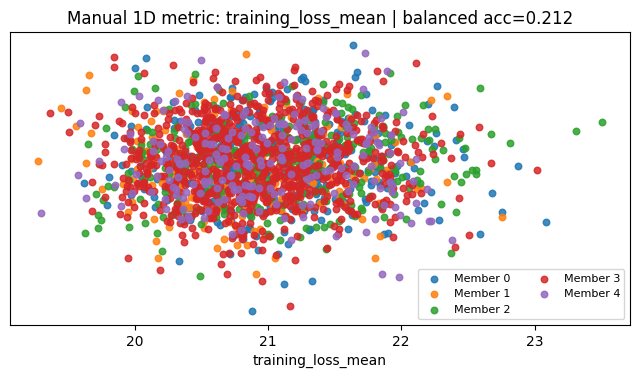

saved_plot: results/penalty_seed0_best_1d_metric.png


In [91]:
x1 = metrics[BEST_1D_METRIC][plot_mask]
rng = np.random.default_rng(0)
y_jitter = rng.normal(0.0, 0.04, size=len(labels))

fig, ax = plt.subplots(figsize=(8, 3.8))
cmap = plt.get_cmap('tab10')
for m in active_members:
    mm = labels == m
    if not np.any(mm):
        continue
    ax.scatter(x1[mm], y_jitter[mm], s=22, alpha=0.85, color=cmap(m), label=f'Member {m}')

ax.set_xlabel(BEST_1D_METRIC)
ax.set_yticks([])
ax.set_title(f'{SELECTED_1D_SOURCE.title()} 1D metric: {BEST_1D_METRIC} | balanced acc={BEST_1D_SCORE:.3f}')
ax.legend(fontsize=8, ncol=max(1, len(active_members) // 2))

os.makedirs(os.path.dirname(OUT_PNG_1D), exist_ok=True)
fig.savefig(OUT_PNG_1D, dpi=180, bbox_inches='tight')
plt.show()
print('saved_plot:', OUT_PNG_1D)


## Best 2D Winner Regions

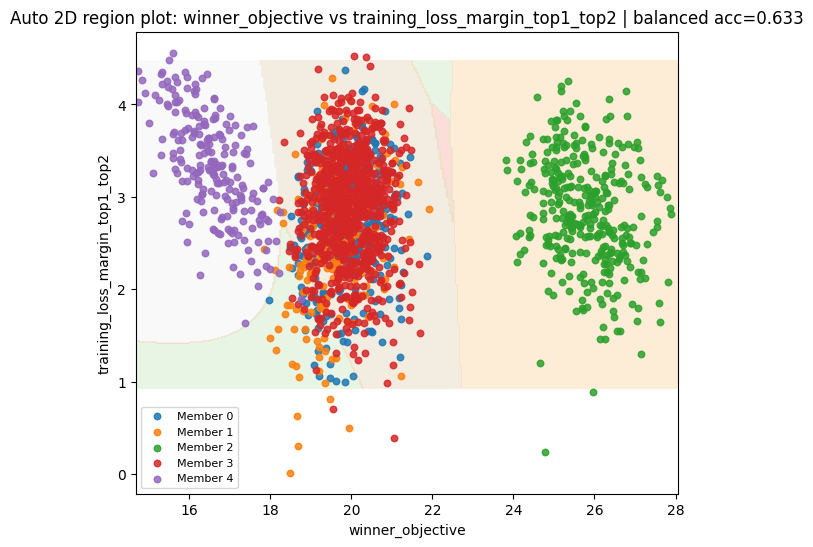

saved_plot: results/penalty_seed0_best_2d_metric.png


In [92]:
x = metrics[X_METRIC][plot_mask]
y = metrics[Y_METRIC][plot_mask]
plot_xy = np.column_stack([x, y])

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=ConvergenceWarning)
    warnings.simplefilter('ignore', category=UserWarning)
    clf = QuadraticDiscriminantAnalysis(reg_param=1e-3)
    clf.fit(plot_xy, labels)

x1_min, x1_max = np.quantile(x, [0.01, 0.99])
x2_min, x2_max = np.quantile(y, [0.01, 0.99])
pad1 = 0.08 * max(x1_max - x1_min, 1e-9)
pad2 = 0.08 * max(x2_max - x2_min, 1e-9)

gx, gy = np.meshgrid(
    np.linspace(x1_min - pad1, x1_max + pad1, 300),
    np.linspace(x2_min - pad2, x2_max + pad2, 300),
)
grid = np.column_stack([gx.ravel(), gy.ravel()])
gz = clf.predict(grid).reshape(gx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
levels = np.arange(gz.max() + 2) - 0.5
ax.contourf(gx, gy, gz, levels=levels, cmap='Pastel1', alpha=0.45)

cmap = plt.get_cmap('tab10')
for m in active_members:
    mm = labels == m
    if not np.any(mm):
        continue
    ax.scatter(x[mm], y[mm], s=22, alpha=0.85, color=cmap(m), label=f'Member {m}')

ax.set_title(f'{SELECTED_2D_SOURCE.title()} 2D region plot: {X_METRIC} vs {Y_METRIC} | balanced acc={BEST_2D_SCORE:.3f}')
ax.set_xlabel(X_METRIC)
ax.set_ylabel(Y_METRIC)
ax.legend(fontsize=8)

os.makedirs(os.path.dirname(OUT_PNG_2D), exist_ok=True)
fig.savefig(OUT_PNG_2D, dpi=180, bbox_inches='tight')
plt.show()
print('saved_plot:', OUT_PNG_2D)
